In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, norm, halfnorm

import torch
import torch.nn as nn
from dataset_creation import create_synthetic_supernovae_dataset, create_torch_supernovae_dataset, z_obs

from config import DATAPOINT_SIZE, LATENT_SIZE, BETA, REGULARIZATION_WEIGHT, DATA_VARIANCE_SCALE, NUM_TRAIN, NUM_TEST, LOAD_DATASET

from Compression.ib import IB
from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE, ConditionalNormalizingFlow

from Compression.Benchmarks.MOPED import moped

from ModelEvaluation.posterior_comparison import evaluate_posterior_covariance
from ModelEvaluation.abc import abc_testing
from ModelEvaluation.coverage_testing import coverage_tests

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)
# torch.cuda.is_available()

Running on device: cuda


In [4]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.12.0+cu132
13.2
True


## Generating a dataseet

In [5]:
# LOAD_DATASET = False

In [6]:
if LOAD_DATASET:
    try:
        train_sims_data = torch.load("train_sims_data.pt")
        test_sims_data = torch.load("test_sims_data.pt")
    except FileNotFoundError:
        print("Data files not found. Creating dataset...")
        train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
        torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
        torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")
else:
    train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
    torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
    torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")

train_sims_data = train_sims_data.to(device)
test_sims_data = test_sims_data.to(device)

Creating sample: 10000 of 10000
Creating sample: 50000 of 50000


## Visualizing the dataset

### Spread of the data with Hubble Parameter
In order to visualize the fact that our data simply moves by a global offset based on the Hubble Constant, we visualize the mean of the data with the Hubble Parameter. This forms quite a linear scatter, showing that the mean is a good representation of the parameter here!

### Each individual datapoint
Each individual datapoint retains the same shape, and only its offset depends on the Hubble constant (can be seen by re-running the cell multiple times and seeing that the shape is retained...alternatively, I can plot all the data-points and subtract their means)  
We notice that the points at low redshift scatter less than those at higher redshifts. This is expected as the lower flux due to the higher redshift appears as a larger scatter

In [7]:
mu = train_sims_data[:, :DATAPOINT_SIZE].detach().cpu()
h0 = train_sims_data[:, -1].detach().cpu()

<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\srish\AppData\Local\Temp\ipykernel_7204\1868757934.py:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.ylabel("Distance Modulus ($\mu$)")


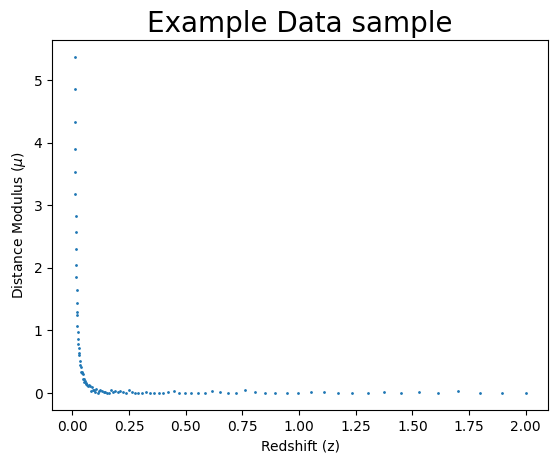

In [8]:
obs_no = np.random.randint(NUM_TRAIN)
flux_obs = 10**(-0.4*mu[obs_no, :])
mu_obs = mu[obs_no, :]
plt.scatter(z_obs, mu_obs, s=1)
# plt.scatter(z_obs, mu_noiseless[obs_no, :], color='red', label='True Signal')
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus ($\mu$)")
# plt.title(f"Obs: {obs_no} | H0: {h0[obs_no]:.2f}")
plt.title('Example Data sample', fontsize=20)
plt.show()

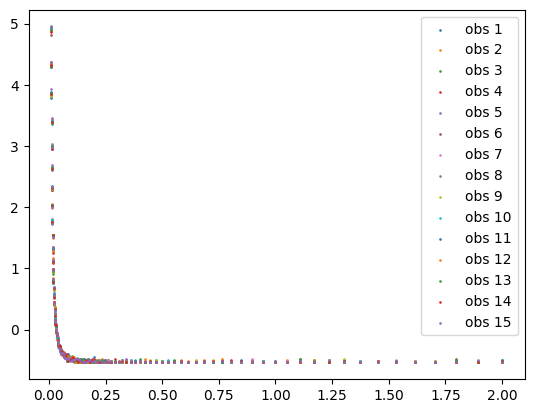

In [9]:
mu_zero_mean = mu - torch.mean(mu, axis=1)[:, None]
mu_zero_mean.shape

for i in range(15):
    plt.scatter(z_obs, mu_zero_mean[i, :], s=0.75, label=f'obs {i+1}')
plt.legend()
plt.show()

## Compression

In [10]:
class Compressor(nn.Module):
    def __init__(self, input_size=DATAPOINT_SIZE, latent_size=LATENT_SIZE):
        super(Compressor, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*latent_size)
        )

    def forward(self, x):
        return self.encoder(x)

In [11]:
model_encoder=Compressor()
model = IB(
    encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
    # cond_prob_model=ConditionalKDE(1, 10),
    cond_prob_model=ConditionalNormalizingFlow(num_flows=8),
    beta = 0e0,
    reg_weight=1e0,
    reg_type=0,
    optim_func=torch.optim.Adam,
    lr=1e-4
).to(device)

Epoch 1: Loss=4.4710, log_q=-3.5805,, reg. loss=0.8904, beta * KL=0.5177
Epoch 10: Loss=0.5003, log_q=-0.4994,, reg. loss=0.0008, beta * KL=9.7191


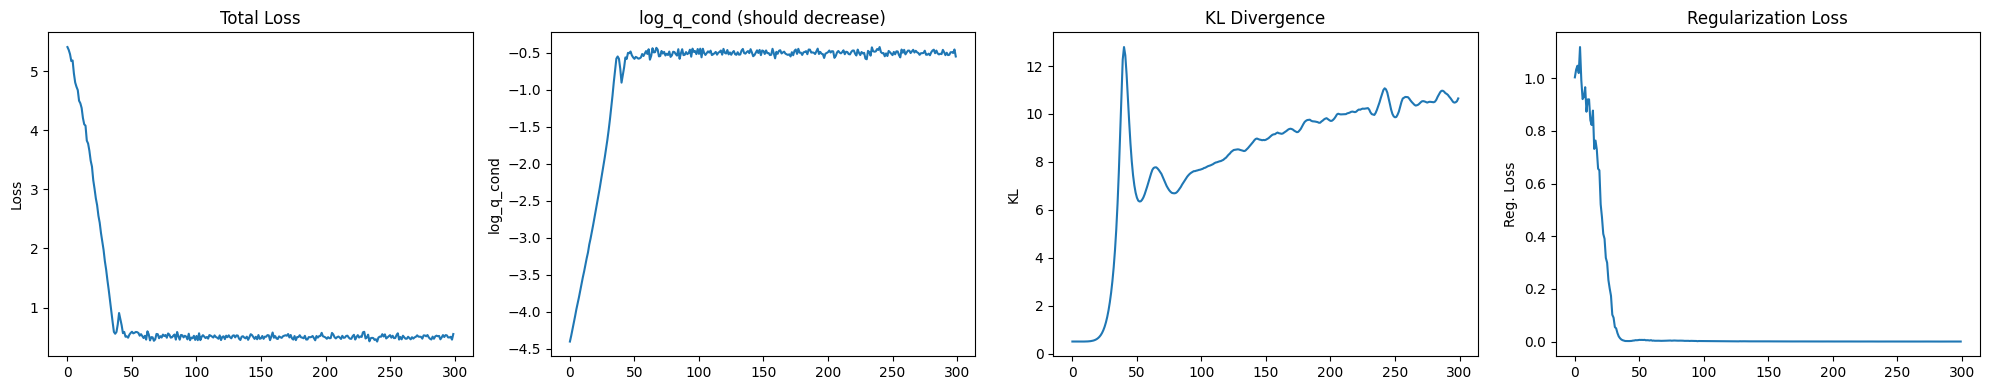

In [12]:
h02s = train_sims_data[:, -1]
h02_norm = (h02s - h02s.mean()) / h02s.std()
h02_norm = h02_norm.unsqueeze(1)   # shape (N, 1) instead of (N,)
model.train(
    x_train=train_sims_data[:, :DATAPOINT_SIZE],
    y_train=h02_norm,
    nepochs=15,
    batch_size=512,
    print_losses=True
    )

assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

In [13]:
# model.encoder(train_sims_data[:, :DATAPOINT_SIZE])
model.encoder.encoder.encoder[0].weight.data

tensor([[-0.0668,  0.0471, -0.0859,  ..., -0.0542, -0.0706, -0.0328],
        [ 0.0756, -0.0026, -0.0748,  ...,  0.0779,  0.0377,  0.0167],
        [ 0.0633,  0.0989, -0.0668,  ...,  0.0004, -0.0627, -0.0408],
        ...,
        [-0.0874,  0.0248,  0.0553,  ..., -0.0549,  0.0777,  0.0028],
        [-0.0822,  0.0152, -0.0068,  ...,  0.0808,  0.0159,  0.0786],
        [ 0.0513, -0.0866,  0.0408,  ...,  0.0237,  0.0235,  0.0940]],
       device='cuda:0')

In [14]:
h02_norm.min(), h02_norm.max()

(tensor(-3.9334, device='cuda:0'), tensor(3.7745, device='cuda:0'))

Latent space range: min=-3.6884, max=-3.5297


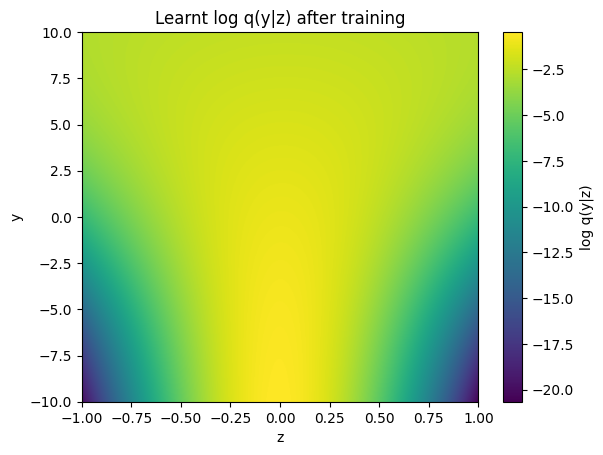

In [15]:
zs = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu()
z_min = zs.min()
z_max = zs.max()
print(f"Latent space range: min={z_min:.4f}, max={z_max:.4f}")

z_min = -1
z_max = 1

y_max = 10
y_min = -1 * y_max

z_values = torch.linspace(z_min, z_max, 500)
y_values = torch.linspace(y_min, y_max, 500)
yz_values = torch.cartesian_prod(z_values, y_values).to(device)
log_q_values = model.cond_prob_model(yz_values[:, 1:], yz_values[:, 0:1]).detach().cpu()

q_values = torch.exp(log_q_values)
plt.imshow(log_q_values.numpy().reshape(500, 500), extent=(z_min, z_max, y_min, y_max), origin='lower', aspect='auto')
plt.colorbar(label='log q(y|z)')
plt.title("Learnt log q(y|z) after training")
plt.xlabel("z")
plt.ylabel("y")
plt.show()

(array([  5.,   5.,   4.,   5.,   4.,   4.,   3.,   3.,   3., 264.]),
 array([-4.40422249, -4.00612795, -3.60803341, -3.20993887, -2.81184433,
        -2.41374978, -2.01565524, -1.6175607 , -1.21946616, -0.82137162,
        -0.42327708]),
 <BarContainer object of 10 artists>)

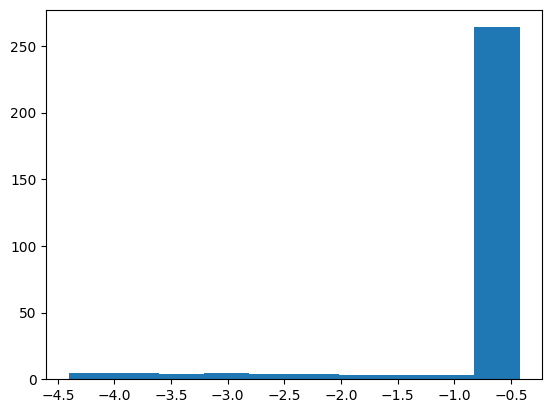

In [16]:
plt.hist(model.log_prob_losses)

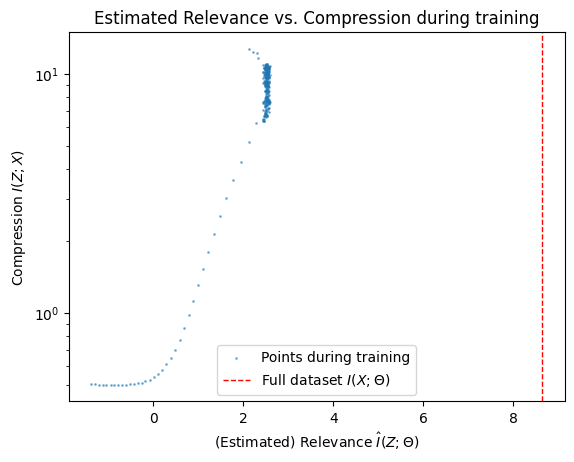

In [ ]:
plt.scatter(np.array(model.log_prob_losses) + 3.02, np.array(model.kl_losses), alpha=0.5, s=1e0,
            label='Points during training')
plt.yscale('log')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)
# plt.axvline(
#     x = 8.64 - 3.02,
#     color='green',
#     linestyle='--',
#     linewidth=1,
#     label=r'Expected model to learn $\hat{I}(X; \Theta)$ without H($\Theta$)'
# )

plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

# TODO: Normalized surrogate??
# TODO: Surrogate is right? Could it just be a good approximation?

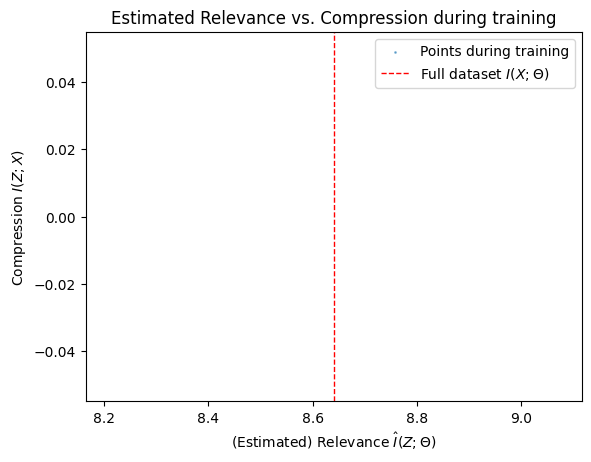

In [18]:
ba_bounds = []
i_z_x = []
for i in range(0):
    print(f"Training new model iteration {i+1}...")
    model_encoder=Compressor()
    model = IB(
        encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
        # cond_prob_model=ConditionalKDE(1, 10),
        cond_prob_model=ConditionalNormalizingFlow(num_flows=8),
        beta = 0e-5,
        reg_weight=1e1,
        reg_type=0,
        optim_func=torch.optim.Adam,
        lr=1e-4 
    ).to(device)

    model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=h02_norm,
        nepochs=40,
        batch_size=512,
        print_losses=True
        )

    assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

    ba_bounds = ba_bounds + model.log_prob_losses
    i_z_x = i_z_x + model.kl_losses

plt.scatter(np.array(ba_bounds), i_z_x, alpha=0.5, s=1e0,
            label='Points during training')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

In [19]:
# plt.scatter(np.array(ba_bounds), i_z_x, alpha=0.5, s=1e-2,
#             label='Points during training')
# plt.axvline(
#     x = 8.64,
#     color='red',
#     linestyle='--',
#     linewidth=1,
#     label=r'Full dataset $I(X; \Theta)$'
# )
# plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
# plt.ylabel(r"Compression $I(Z;X)$")
# plt.legend()
# plt.title('Estimated Relevance vs. Compression during training')
# plt.show()

In [20]:
# np.save("ba_bounds.npy", np.array(ba_bounds), allow_pickle=True)
# np.save("i_z_x.npy", i_z_x, allow_pickle=True)

## Plotting the results to compare estimator std dev

-3.518176 -3.7201467


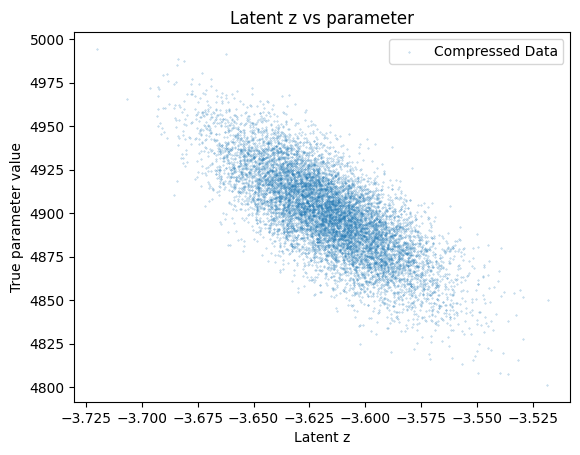

In [21]:
m, l, z = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])
z = z.detach().cpu().numpy()

print(z.max(), z.min())

plt.scatter(z, train_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1e-1, label='Compressed Data')
plt.xlabel('Latent z')
plt.ylabel('True parameter value')
plt.legend()
# plt.xlim([110, 120])
plt.title('Latent z vs parameter')
plt.show()

In [22]:
# To check if the model collapsed: the standard deviations in m must match the priors
m.std(), l.std()

(tensor(0.0197, device='cuda:0', grad_fn=<StdBackward0>),
 tensor(0.0453, device='cuda:0', grad_fn=<StdBackward0>))

Dataset size: 50000, Number of bins: 11, Bin width: 0.00
Bin centers: [-3.6812246 -3.6667967 -3.652369  -3.6379414 -3.6235137 -3.609086
 -3.5946581 -3.5802305 -3.5658028 -3.551375  -3.5369473]
Bin means: [4978.98291015625, 4959.82568359375, 4943.845703125, 4926.65478515625, 4908.7509765625, 4891.4169921875, 4873.19775390625, 4856.2578125, 4837.92822265625, 4815.38623046875, nan]
Bin stds: [10.019097328186035, 7.946016311645508, 8.724169731140137, 8.324230194091797, 8.352622985839844, 8.4059419631958, 8.171167373657227, 8.43000602722168, 8.216463088989258, 9.2662353515625, nan]
Bin stds errors: [np.float64(3.1683167655975395), np.float64(0.7253687293653741), np.float64(0.3486879503762736), np.float64(0.2008318097021967), np.float64(0.1523957707853328), np.float64(0.1504905017539186), np.float64(0.1942215757305996), np.float64(0.35623277306467205), np.float64(0.7834090171268535), np.float64(2.930240904610858), nan]


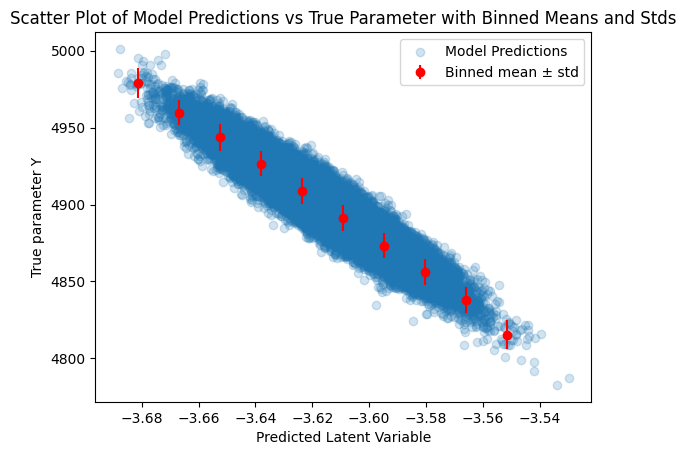

(np.float64(8.351255841973627),
 array([10.01909733,  7.94601631,  8.72416973,  8.32423019,  8.35262299,
         8.40594196,  8.17116737,  8.43000603,  8.21646309,  9.26623535]),
 array([3.16831677, 0.72536873, 0.34868795, 0.20083181, 0.15239577,
        0.1504905 , 0.19422158, 0.35623277, 0.78340902, 2.9302409 ]))

In [23]:
sigma_beta, _, std, std_err = evaluate_posterior_covariance(model, test_sims_data[:, :DATAPOINT_SIZE], test_sims_data[:, -1:])
sigma_beta, std, std_err

## Posterior comparison

In [46]:
SELECT_PERCENT = 0.25e-3
show_h0_instead_of_h02 = False

In [54]:
true_h02 = 69.95**2
# true_h0 = test_sims_data[0, -1].item()
_, data_obs, _, _ = create_synthetic_supernovae_dataset(n_samples=1, h02s=[true_h02])
data_obs = torch.tensor(data_obs, dtype=torch.float32).to(device)

y_data_abc = test_sims_data[:, -1:].detach().cpu()
shown_true_param = true_h02
param_name = '$H_0^2$' if not show_h0_instead_of_h02 else '$H_0$'

if show_h0_instead_of_h02:
    y_data_abc = torch.sqrt(y_data_abc)
    shown_true_param = np.sqrt(true_h02)


Creating sample: 1 of 1


Compressed obs: -3.617584705352783
Selected 1776 samples from test set with compressed value close to observed compressed value.


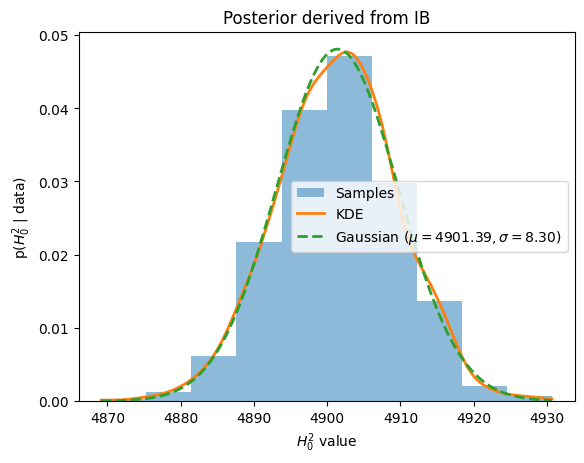

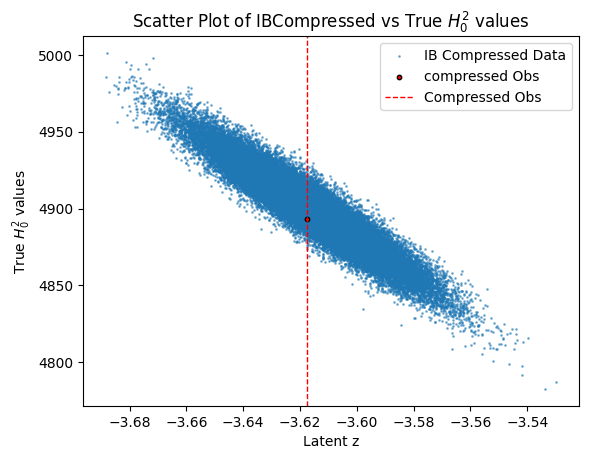

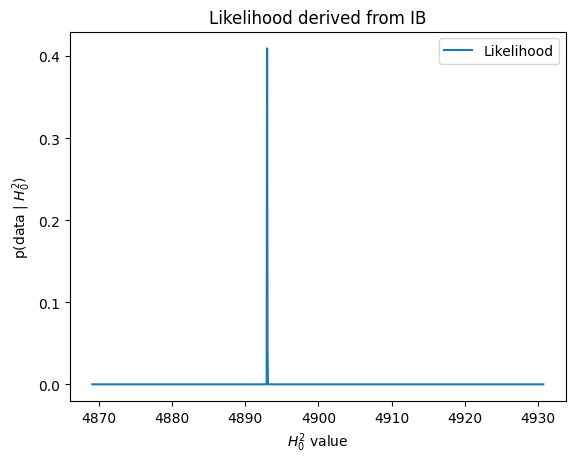

((np.float32(4901.392), np.float32(8.298275)),
 1.0110111236572266,
 0.15315315315315314,
 1776)

In [55]:
compressed_test = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu().numpy()

compressed_obs = model(data_obs).detach().cpu().numpy()

print("Compressed obs:", compressed_obs.item())

abc_testing(compressed_obs, compressed_test, 
            y_data=y_data_abc,
            true_param=shown_true_param,
            param_name=param_name,
            method_name='IB')

### MOPED Compression

Creating sample: 1 of 1
Creating sample: 1 of 1
Creating sample: 1 of 1
(1, 100)
MOPED Fisher information: [[1.6e-07]]


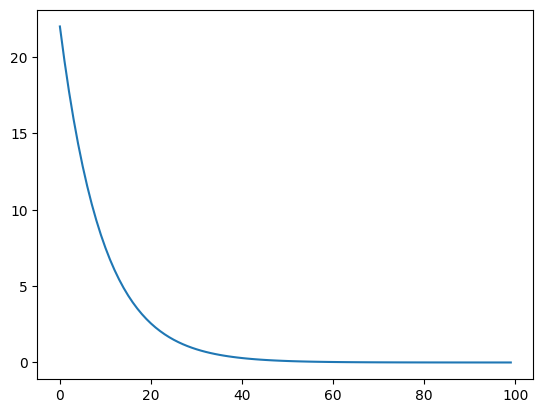

In [28]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE**2

def estimator_given_theta(theta):
    _, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    # print(data.shape)
    # return 10**(-0.4*data[0, :])
    return data[0, :]

fid_vals = np.array([70.0**2])

b, F, d = moped(fid_vals, cov, estimator_given_theta)
# print("MOPED compressed value:", b)
print("MOPED Fisher information:", 1/F)
plt.plot(b.T)
plt.show()

In [29]:
def moped_model(data):
    if (type(data) != np.ndarray):
        data = data.detach().cpu().numpy()
    return data[:, :DATAPOINT_SIZE] @ b.T
moped_compressed = moped_model(data_obs)
moped_test = moped_model(test_sims_data)
moped_compressed

array([[614.53017399]])

Selected 7301 samples from test set with compressed value close to observed compressed value.


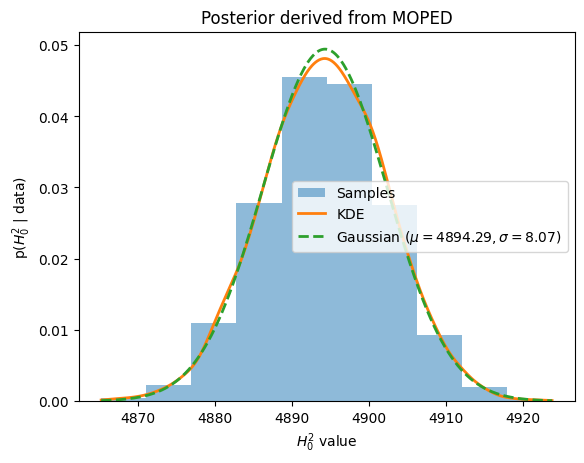

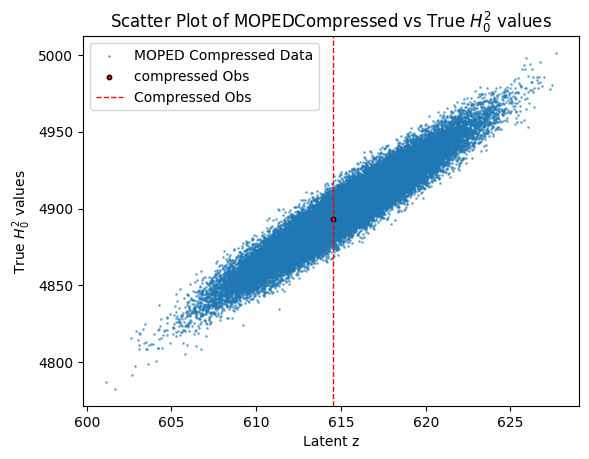

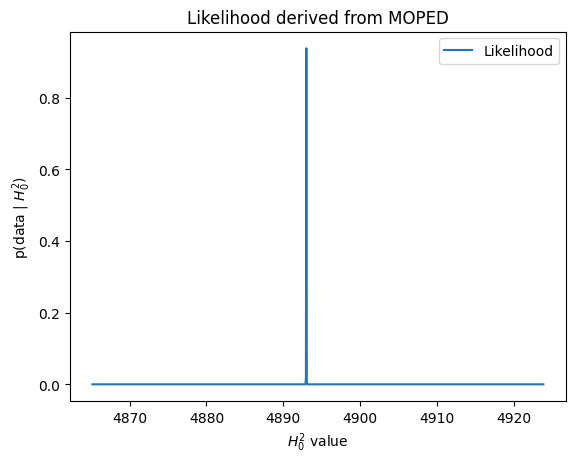

((np.float32(4894.2876), np.float32(8.07319)),
 0.1591881662607193,
 0.4369264484317217,
 7301)

In [30]:
abc_testing(moped_compressed, moped_test, y_data_abc, true_param=shown_true_param)

# Coverage Testing

Creating sample: 10000 of 10000
Creating sample: 1 of 1


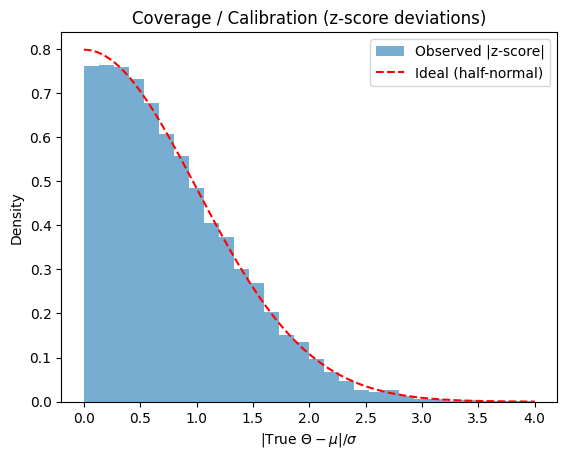

Fraction within 1σ: 0.681  (ideal ≈ 0.683)
Fraction within 2σ: 0.957  (ideal ≈ 0.954)


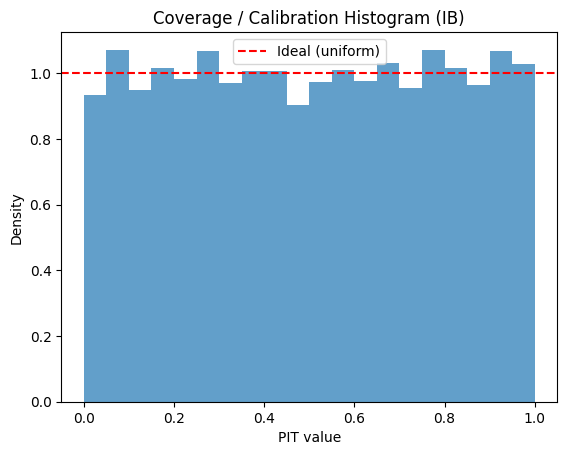

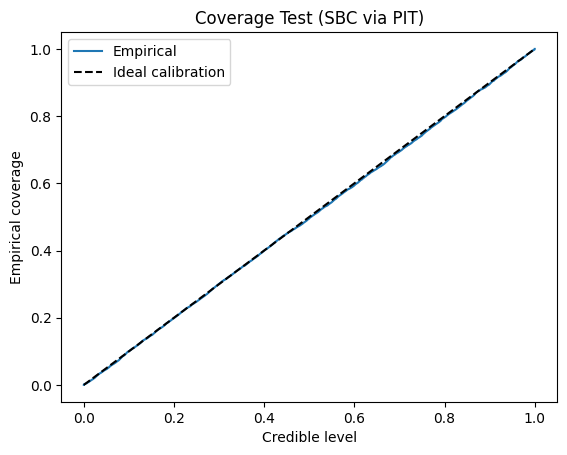

In [58]:
z_scores, pit_values= coverage_tests(10000, model, test_sims_data, "IB")

In [59]:
coverage_tests(10000, moped_model, test_sims_data, "MOPED")

Creating sample: 10000 of 10000
Creating sample: 1 of 1


ValueError: `dataset` input should have multiple elements.